### Step 1 : Loading Json Data and Converting it into DataFrame

In [1]:
import json
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading json data
file_path = "../data/dataset-template.json"
with open(file_path, "r") as f:
    data = json.load(f)

In [3]:
# Extracting Records 
records = data["sample_records"]
print(len(records))
records[0]

10


{'business_id': 'BUS-00001',
 'gst_filing_delay_days_avg': 2.5,
 'num_payment_defaults_12m': 0,
 'total_overdue_amount_usd': 0,
 'blocklist_flag': False,
 'legal_notice_count_12m': 0,
 'return_bounce_rate': 0.0,
 'business_age_months': 120,
 'annual_turnover_band': '10M-100M',
 'profile_completeness_score': 0.95,
 'geography_risk_index': 0.2,
 'sector_risk_index': 0.35}

In [4]:
# Converting to DataFrame
df = pd.DataFrame(records)
df.sample(5)

,business_id,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,blocklist_flag,legal_notice_count_12m,return_bounce_rate,business_age_months,annual_turnover_band,profile_completeness_score,geography_risk_index,sector_risk_index
0,BUS-00001,2.5,0.0,0.0,False,0,0.00,120,10M-100M,0.95,0.20,0.35
8,BUS-00009,60.0,NaN,15000.0,True,1,NaN,9,<1M,0.50,0.60,0.50
6,BUS-00007,NaN,5.0,65000.0,True,3,0.40,8,1M-10M,0.30,0.80,0.75
7,BUS-00008,3.5,0.0,0.0,False,0,0.02,96,10M-100M,0.92,0.25,0.30
9,BUS-00010,5.0,0.0,0.0,False,0,0.00,144,>100M,0.99,0.15,0.25


In [5]:
# checking the information about df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   business_id                 10 non-null     object 
 1   gst_filing_delay_days_avg   8 non-null      float64
 2   num_payment_defaults_12m    8 non-null      float64
 3   total_overdue_amount_usd    9 non-null      float64
 4   blocklist_flag              10 non-null     bool   
 5   legal_notice_count_12m      10 non-null     int64  
 6   return_bounce_rate          8 non-null      float64
 7   business_age_months         10 non-null     int64  
 8   annual_turnover_band        10 non-null     object 
 9   profile_completeness_score  10 non-null     float64
 10  geography_risk_index        10 non-null     float64
 11  sector_risk_index           10 non-null     float64
dtypes: bool(1), float64(7), int64(2), object(2)
memory usage: 1018.0+ bytes


In [6]:
# Checking for missing values
df.isnull().sum()

business_id                   0
gst_filing_delay_days_avg     2
num_payment_defaults_12m      2
total_overdue_amount_usd      1
blocklist_flag                0
legal_notice_count_12m        0
return_bounce_rate            2
business_age_months           0
annual_turnover_band          0
profile_completeness_score    0
geography_risk_index          0
sector_risk_index             0
dtype: int64

In [7]:
# Basic Statistics
df.describe()

,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,legal_notice_count_12m,return_bounce_rate,business_age_months,profile_completeness_score,geography_risk_index,sector_risk_index
count,8.000000,8.000000,9.000000,10.00000,8.000000,10.000000,10.00000,10.000000,10.000000
mean,18.375000,1.375000,13044.444444,0.70000,0.105000,69.000000,0.72100,0.400000,0.475000
std,22.412927,1.846812,21316.197545,1.05935,0.147164,63.319297,0.26117,0.241523,0.204464
min,1.000000,0.000000,0.000000,0.00000,0.000000,8.000000,0.30000,0.100000,0.200000
25%,3.250000,0.000000,0.000000,0.00000,0.000000,11.750000,0.51250,0.212500,0.312500
50%,6.500000,0.500000,3500.000000,0.00000,0.035000,54.000000,0.79000,0.350000,0.475000
75%,27.750000,2.250000,15000.000000,1.00000,0.152500,114.000000,0.94250,0.575000,0.587500
max,60.000000,5.000000,65000.000000,3.00000,0.400000,180.000000,1.00000,0.800000,0.800000


In [8]:
# Checking the categorical values
df["annual_turnover_band"].value_counts()

annual_turnover_band
10M-100M    3
1M-10M      3
<1M         2
>100M       2
Name: count, dtype: int64

In [9]:
df

,business_id,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,blocklist_flag,legal_notice_count_12m,return_bounce_rate,business_age_months,annual_turnover_band,profile_completeness_score,geography_risk_index,sector_risk_index
0,BUS-00001,2.5,0.0,0.0,False,0,0.00,120,10M-100M,0.95,0.20,0.35
1,BUS-00002,NaN,3.0,25000.0,True,2,0.25,14,1M-10M,0.55,0.70,0.80
2,BUS-00003,8.0,1.0,3500.0,False,0,0.05,72,10M-100M,0.88,0.30,0.45
3,BUS-00004,45.0,NaN,NaN,False,1,NaN,11,<1M,0.42,0.50,0.60
4,BUS-00005,1.0,0.0,0.0,False,0,0.00,180,>100M,1.00,0.10,0.20
5,BUS-00006,22.0,2.0,8900.0,False,0,0.12,36,1M-10M,0.70,0.40,0.55
6,BUS-00007,NaN,5.0,65000.0,True,3,0.40,8,1M-10M,0.30,0.80,0.75
7,BUS-00008,3.5,0.0,0.0,False,0,0.02,96,10M-100M,0.92,0.25,0.30
8,BUS-00009,60.0,NaN,15000.0,True,1,NaN,9,<1M,0.50,0.60,0.50
9,BUS-00010,5.0,0.0,0.0,False,0,0.00,144,>100M,0.99,0.15,0.25


### Step 2 : Data Cleaning

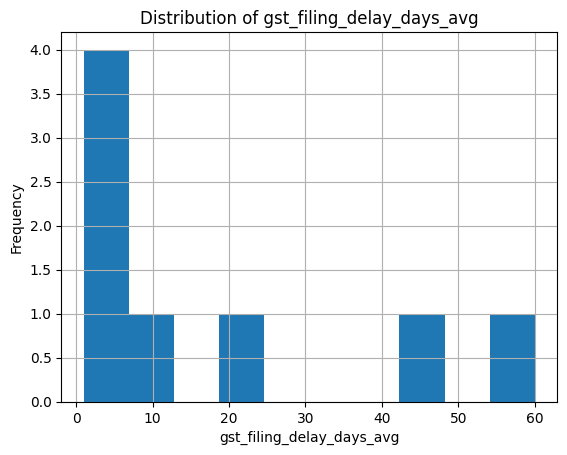

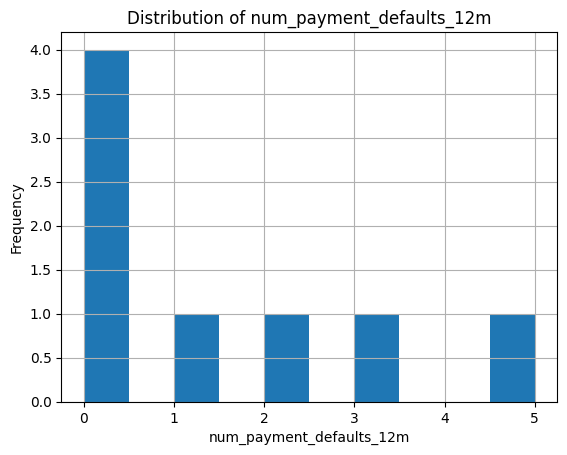

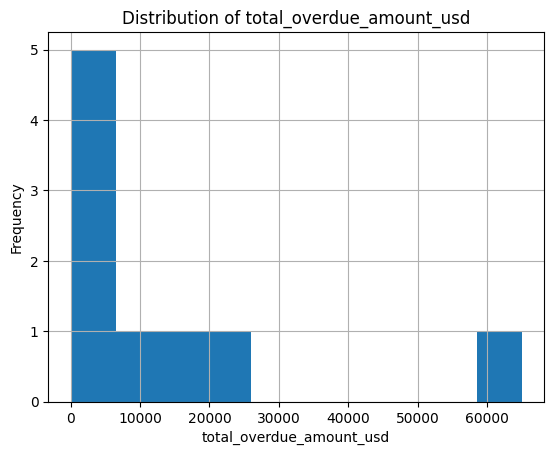

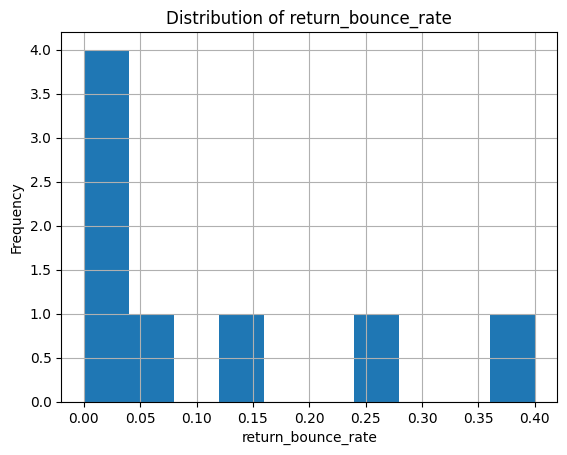

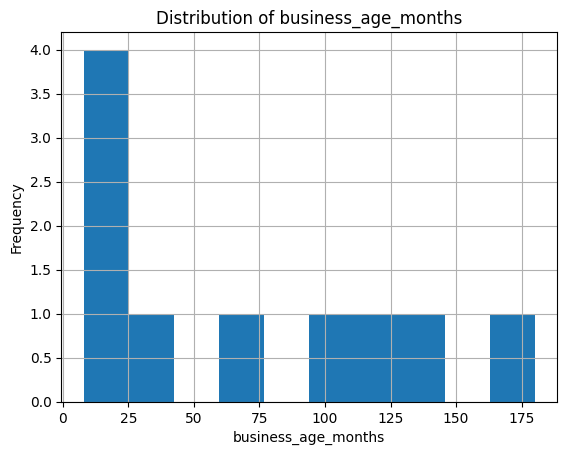

In [10]:
# Visualizing the distribution of numeric columns for better strategies of missing values

import matplotlib.pyplot as plt

numeric_cols = [
    "gst_filing_delay_days_avg",
    "num_payment_defaults_12m",
    "total_overdue_amount_usd",
    "return_bounce_rate",
    "business_age_months"
]

for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=10)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

- The Distributions are heavy skewed to one side so we are going to use median because robust to outliers

In [11]:
# checking missing values %%!
missing_percentage = (df.isnull().sum()/ len(df)) * 100
print(missing_percentage)

business_id                    0.0
gst_filing_delay_days_avg     20.0
num_payment_defaults_12m      20.0
total_overdue_amount_usd      10.0
blocklist_flag                 0.0
legal_notice_count_12m         0.0
return_bounce_rate            20.0
business_age_months            0.0
annual_turnover_band           0.0
profile_completeness_score     0.0
geography_risk_index           0.0
sector_risk_index              0.0
dtype: float64


In [12]:
# Using Median To the Numeric Missing cols
# And tagging the missing cols for confiedence calculations 
numeric_cols = [
    "gst_filing_delay_days_avg",
    "num_payment_defaults_12m",
    "total_overdue_amount_usd",
    "return_bounce_rate"
]

for col in numeric_cols:
    df[col + "_missing"] = df[col].isnull().astype(int)
    median_value = df[col].median()
    df[col].fillna(median_value,inplace=True)

In [13]:
df.isnull().sum()

business_id                          0
gst_filing_delay_days_avg            0
num_payment_defaults_12m             0
total_overdue_amount_usd             0
blocklist_flag                       0
legal_notice_count_12m               0
return_bounce_rate                   0
business_age_months                  0
annual_turnover_band                 0
profile_completeness_score           0
geography_risk_index                 0
sector_risk_index                    0
gst_filing_delay_days_avg_missing    0
num_payment_defaults_12m_missing     0
total_overdue_amount_usd_missing     0
return_bounce_rate_missing           0
dtype: int64

In [14]:
df

,business_id,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,blocklist_flag,legal_notice_count_12m,return_bounce_rate,business_age_months,annual_turnover_band,profile_completeness_score,geography_risk_index,sector_risk_index,gst_filing_delay_days_avg_missing,num_payment_defaults_12m_missing,total_overdue_amount_usd_missing,return_bounce_rate_missing
0,BUS-00001,2.5,0.0,0.0,False,0,0.000,120,10M-100M,0.95,0.20,0.35,0,0,0,0
1,BUS-00002,6.5,3.0,25000.0,True,2,0.250,14,1M-10M,0.55,0.70,0.80,1,0,0,0
2,BUS-00003,8.0,1.0,3500.0,False,0,0.050,72,10M-100M,0.88,0.30,0.45,0,0,0,0
3,BUS-00004,45.0,0.5,3500.0,False,1,0.035,11,<1M,0.42,0.50,0.60,0,1,1,1
4,BUS-00005,1.0,0.0,0.0,False,0,0.000,180,>100M,1.00,0.10,0.20,0,0,0,0
5,BUS-00006,22.0,2.0,8900.0,False,0,0.120,36,1M-10M,0.70,0.40,0.55,0,0,0,0
6,BUS-00007,6.5,5.0,65000.0,True,3,0.400,8,1M-10M,0.30,0.80,0.75,1,0,0,0
7,BUS-00008,3.5,0.0,0.0,False,0,0.020,96,10M-100M,0.92,0.25,0.30,0,0,0,0
8,BUS-00009,60.0,0.5,15000.0,True,1,0.035,9,<1M,0.50,0.60,0.50,0,1,0,1
9,BUS-00010,5.0,0.0,0.0,False,0,0.000,144,>100M,0.99,0.15,0.25,0,0,0,0


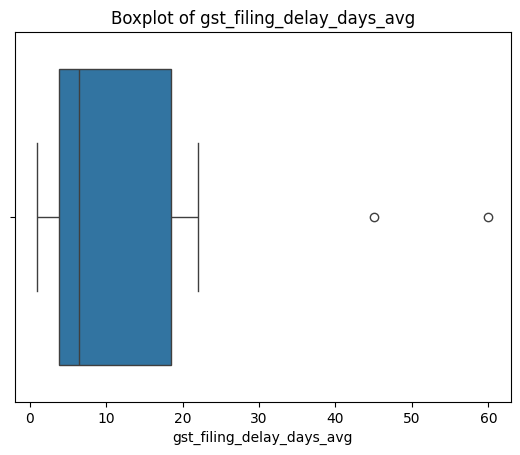

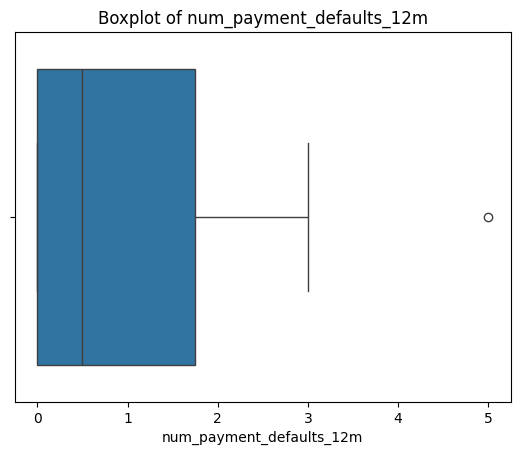

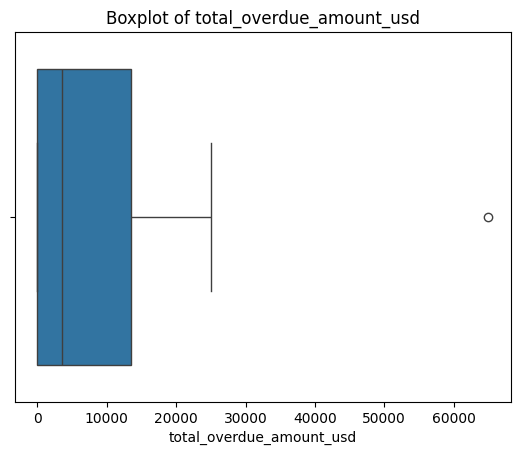

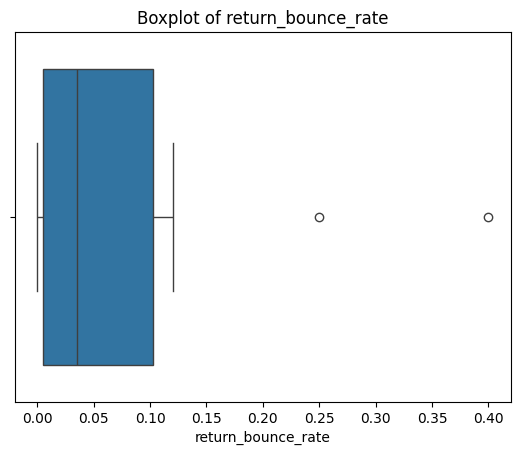

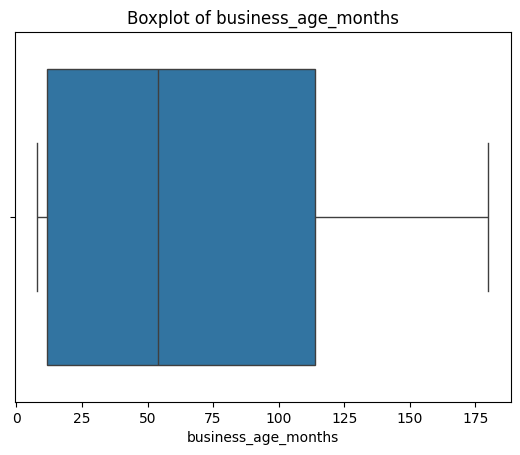

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    "gst_filing_delay_days_avg",
    "num_payment_defaults_12m",
    "total_overdue_amount_usd",
    "return_bounce_rate",
    "business_age_months"
]

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [16]:
# Outliers Handling 
# Using the IQR method to prevent extreme values dominating the model
# Keeps distribution shape mostly same
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

for col in numeric_cols:
    cap_outliers(col)

In [19]:
df.describe()

,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,legal_notice_count_12m,return_bounce_rate,business_age_months,profile_completeness_score,geography_risk_index,sector_risk_index,gst_filing_delay_days_avg_missing,num_payment_defaults_12m_missing,total_overdue_amount_usd_missing,return_bounce_rate_missing
count,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,13.587500,1.137500,8958.750000,0.70000,0.075750,69.000000,0.72100,0.400000,0.475000,0.200000,0.200000,0.100000,0.200000
std,15.279548,1.516632,11953.454362,1.05935,0.097822,63.319297,0.26117,0.241523,0.204464,0.421637,0.421637,0.316228,0.421637
min,1.000000,0.000000,0.000000,0.00000,0.000000,8.000000,0.30000,0.100000,0.200000,0.000000,0.000000,0.000000,0.000000
25%,3.875000,0.000000,0.000000,0.00000,0.005000,11.750000,0.51250,0.212500,0.312500,0.000000,0.000000,0.000000,0.000000
50%,6.500000,0.500000,3500.000000,0.00000,0.035000,54.000000,0.79000,0.350000,0.475000,0.000000,0.000000,0.000000,0.000000
75%,18.500000,1.750000,13475.000000,1.00000,0.102500,114.000000,0.94250,0.575000,0.587500,0.000000,0.000000,0.000000,0.000000
max,40.437500,4.375000,33687.500000,3.00000,0.248750,180.000000,1.00000,0.800000,0.800000,1.000000,1.000000,1.000000,1.000000


In [20]:
df

,business_id,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,blocklist_flag,legal_notice_count_12m,return_bounce_rate,business_age_months,annual_turnover_band,profile_completeness_score,geography_risk_index,sector_risk_index,gst_filing_delay_days_avg_missing,num_payment_defaults_12m_missing,total_overdue_amount_usd_missing,return_bounce_rate_missing
0,BUS-00001,2.5000,0.000,0.0,False,0,0.00000,120,10M-100M,0.95,0.20,0.35,0,0,0,0
1,BUS-00002,6.5000,3.000,25000.0,True,2,0.24875,14,1M-10M,0.55,0.70,0.80,1,0,0,0
2,BUS-00003,8.0000,1.000,3500.0,False,0,0.05000,72,10M-100M,0.88,0.30,0.45,0,0,0,0
3,BUS-00004,40.4375,0.500,3500.0,False,1,0.03500,11,<1M,0.42,0.50,0.60,0,1,1,1
4,BUS-00005,1.0000,0.000,0.0,False,0,0.00000,180,>100M,1.00,0.10,0.20,0,0,0,0
5,BUS-00006,22.0000,2.000,8900.0,False,0,0.12000,36,1M-10M,0.70,0.40,0.55,0,0,0,0
6,BUS-00007,6.5000,4.375,33687.5,True,3,0.24875,8,1M-10M,0.30,0.80,0.75,1,0,0,0
7,BUS-00008,3.5000,0.000,0.0,False,0,0.02000,96,10M-100M,0.92,0.25,0.30,0,0,0,0
8,BUS-00009,40.4375,0.500,15000.0,True,1,0.03500,9,<1M,0.50,0.60,0.50,0,1,0,1
9,BUS-00010,5.0000,0.000,0.0,False,0,0.00000,144,>100M,0.99,0.15,0.25,0,0,0,0


### Step 3 : Feature Engineering

- Step 1 Creating Risk based Buckets using Threshold

In [21]:
## gst filing delays > 15 keeping it as a high filing delay
df["high_filing_delay"] = (df["gst_filing_delay_days_avg"] > 15).astype(int)

In [22]:
# payment defaults > 2 keeping it high default risk
# Because clear financial instability
df["high_default_risk"] = (df["num_payment_defaults_12m"] > 2).astype(int)

In [23]:
# Over due amount > 10000 keeping it as a high overdue risk
df["high_overdue_risk"] = (df["total_overdue_amount_usd"] > 10000).astype(int)

In [24]:
# bounce rate > 0.15 keeping it as a high bounce eisk
df["high_bounce_risk"] = (df["return_bounce_rate"] > 0.15).astype(int)

- Step 2 : Business Stability Features

In [25]:
# business age months < 24 keeping it as a young business
# Because new business are unstable
df["young_business"] = (df["business_age_months"] < 24).astype(int)

In [26]:
# business age months > 60 keeping it as mature business
# Because old business are stable
df["mature_business"] = (df["business_age_months"] > 60).astype(int)

- Step 3 : Profile Quality Features

In [27]:
# Incomplete profiles increase uncertainty and risk.
# profile completeness score < 0.6 keeping it as low profile
df["low_profile"] = (df["profile_completeness_score"] < 0.6).astype(int)

In [28]:
# profile completeness score > 0.9 keeping it as low profile
df["high_profile"] = (df["profile_completeness_score"] > 0.9).astype(int)

- Step 4 : Risk Index Features by sector and Geography

In [29]:
# geographic risk index > 0.6 keeping it as high geo risk
df["high_geo_risk"] = (df["geography_risk_index"] > 0.6).astype(int)

In [30]:
# same for the sector
df["high_sector_risk"] = (df["sector_risk_index"] > 0.6).astype(int)

In [31]:
# turn over band changing to numeric from categorical
turnover_map = {
    "<1M":0,
    "1M-10M":1,
    "10M-100M":2,
    ">100M": 3
}

df["turnover_score"] = df["annual_turnover_band"].map(turnover_map)

- Step 5 : Composite Risk Score to create a stronger features

In [32]:
# Combining multiple weak signals creates a stronger overall risk indicator.
df["total_risk_flags"] = (
    df["high_default_risk"] +
    df["high_overdue_risk"] +
    df["high_filing_delay"] +
    df["high_bounce_risk"] +
    df["low_profile"] +
    df["high_geo_risk"] +
    df["high_sector_risk"]
)

- Step 6 : Interaction Features like default and overdue risk

In [33]:
# Interaction features capture combined effects of multiple risk factors.
# Defaults + overdue together = strong signal
df["financial_stress"] = (
    (df["high_default_risk"] == 1) &
    (df["high_overdue_risk"] == 1)
).astype(int)

- Step 7 : Missing Impact Features

In [34]:
# Missing data itself can be a signal of poor reporting or risk.
missing_cols = [col for col in df.columns if "_missing" in col]

df["total_missing_flags"] = df[missing_cols].sum(axis=1)

In [36]:
df.corr(numeric_only=True)

,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,blocklist_flag,legal_notice_count_12m,return_bounce_rate,business_age_months,profile_completeness_score,geography_risk_index,sector_risk_index,...,young_business,mature_business,low_profile,high_profile,high_geo_risk,high_sector_risk,turnover_score,total_risk_flags,financial_stress,total_missing_flags
gst_filing_delay_days_avg,1.000000,-0.068003,0.082792,0.190812,0.125363,-0.083121,-0.633900,-0.591767,0.400631,0.323313,...,0.556589,-0.661414,0.556589,-0.596370,-0.244473,-0.244473,-0.826830,0.171673,-0.244473,0.824252
num_payment_defaults_12m,-0.068003,1.000000,0.925632,0.676810,0.841125,0.972015,-0.640845,-0.700967,0.818997,0.852108,...,0.542656,-0.651583,0.542656,-0.645512,0.886153,0.886153,-0.385767,0.848826,0.886153,0.132263
total_overdue_amount_usd,0.082792,0.925632,1.000000,0.900795,0.937571,0.921982,-0.707012,-0.799243,0.922708,0.853844,...,0.744357,-0.728282,0.744357,-0.645041,0.898806,0.898806,-0.514572,0.958965,0.898806,0.320063
blocklist_flag,0.190812,0.676810,0.900795,1.000000,0.846826,0.717774,-0.639360,-0.716037,0.857143,0.703124,...,0.801784,-0.654654,0.801784,-0.534522,0.763763,0.763763,-0.532397,0.904855,0.763763,0.412556
legal_notice_count_12m,0.125363,0.841125,0.937571,0.846826,1.000000,0.840079,-0.680807,-0.854204,0.911967,0.833594,...,0.853067,-0.696526,0.853067,-0.568711,0.895533,0.895533,-0.534081,0.962731,0.895533,0.504950
return_bounce_rate,-0.083121,0.972015,0.921982,0.717774,0.840079,1.000000,-0.650358,-0.678977,0.830643,0.881896,...,0.581784,-0.665394,0.581784,-0.622476,0.932090,0.932090,-0.398290,0.892007,0.932090,0.152522
business_age_months,-0.633900,-0.640845,-0.707012,-0.639360,-0.680807,-0.650358,1.000000,0.908192,-0.910362,-0.896423,...,-0.795157,0.888963,-0.795157,0.897100,-0.482770,-0.482770,0.927650,-0.737028,-0.482770,-0.679150
profile_completeness_score,-0.591767,-0.700967,-0.799243,-0.716037,-0.854204,-0.678977,0.908192,1.000000,-0.945028,-0.875469,...,-0.917771,0.916180,-0.917771,0.804079,-0.597333,-0.597333,0.868498,-0.843409,-0.597333,-0.777900
geography_risk_index,0.400631,0.818997,0.922708,0.857143,0.911967,0.830643,-0.910362,-0.945028,1.000000,0.939374,...,0.890871,-0.872872,0.890871,-0.801784,0.763763,0.763763,-0.787948,0.942558,0.763763,0.607978
sector_risk_index,0.323313,0.852108,0.853844,0.703124,0.833594,0.881896,-0.896423,-0.875469,0.939374,1.000000,...,0.789255,-0.850640,0.789255,-0.841872,0.773309,0.773309,-0.742094,0.890716,0.773309,0.525805


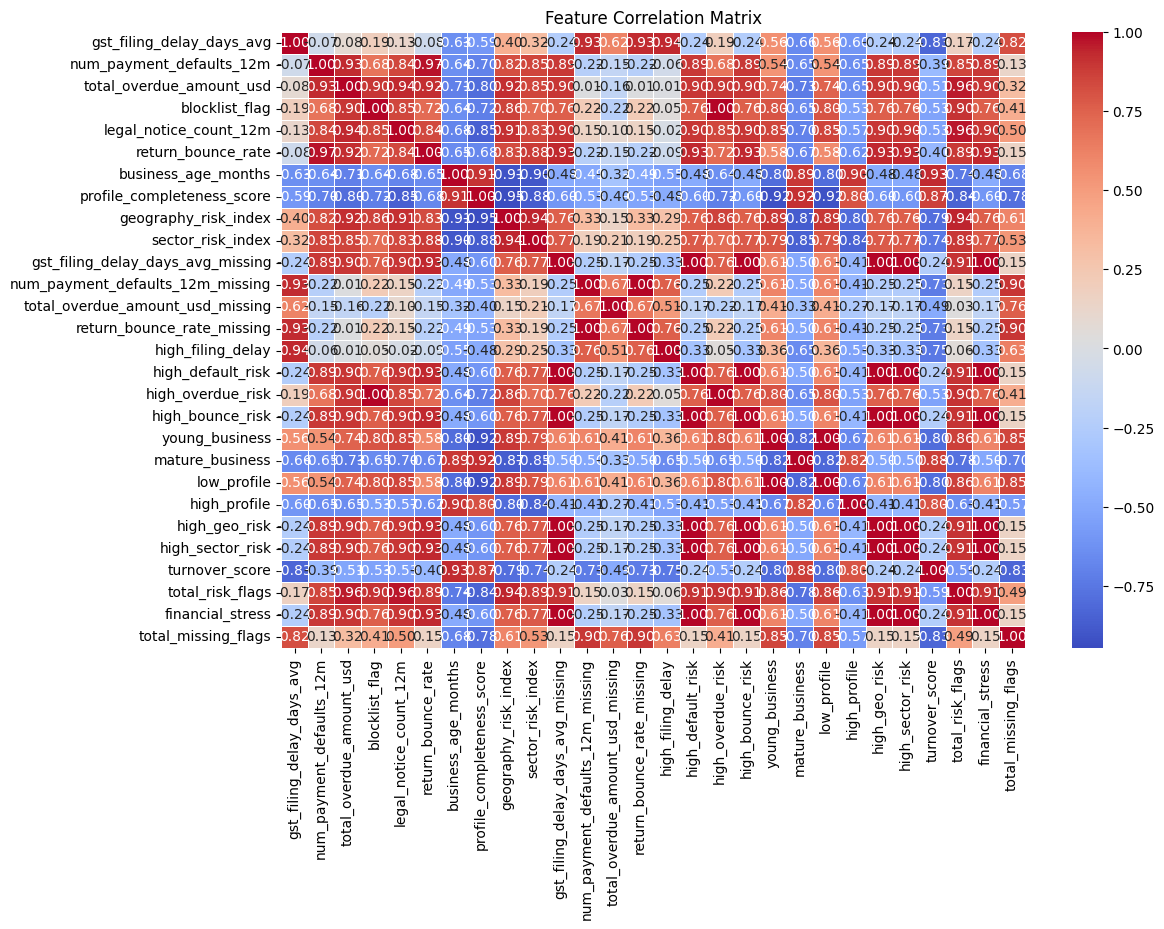

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation
corr = df.corr(numeric_only=True)

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()

In [42]:
df.shape

(10, 30)

#### Step 4 :Risk Scoring Model

- Step 1 : Defining Feature Weights 

In [47]:
# Higher weights are assigned to features strongly correlated with financial risk and regulatory issues.
# Define weights (based on correlation + domain importance)

weights = {
    "blocklist_flag": 40,          
    "high_default_risk": 20,
    "high_overdue_risk": 15,
    "financial_stress": 10,
    "high_bounce_risk": 10,
    "high_filing_delay": 5,
    "low_profile": 5,
    "high_geo_risk": 5,
    "high_sector_risk": 5,
    "young_business": 5,
    "mature_business": -5,         
    "high_profile": -5,            
    "turnover_score": -3           
}


- Step 2 : Calculating Raw Score

In [49]:
# Risk score is computed as a weighted sum of engineered features.
def calculate_score(row):
    score = 0

    for feature, weight in weights.items():
        score += row[feature] * weight

    return score

In [50]:
df["raw_score"] = df.apply(calculate_score, axis=1)

In [51]:
df

,business_id,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,blocklist_flag,legal_notice_count_12m,return_bounce_rate,business_age_months,annual_turnover_band,profile_completeness_score,...,mature_business,low_profile,high_profile,high_geo_risk,high_sector_risk,turnover_score,total_risk_flags,financial_stress,total_missing_flags,raw_score
0,BUS-00001,2.5000,0.000,0.0,False,0,0.00000,120,10M-100M,0.95,...,1,0,1,0,0,2,0,0,0,-16
1,BUS-00002,6.5000,3.000,25000.0,True,2,0.24875,14,1M-10M,0.55,...,0,1,0,1,1,1,6,1,1,112
2,BUS-00003,8.0000,1.000,3500.0,False,0,0.05000,72,10M-100M,0.88,...,1,0,0,0,0,2,0,0,0,-11
3,BUS-00004,40.4375,0.500,3500.0,False,1,0.03500,11,<1M,0.42,...,0,1,0,0,0,0,2,0,3,15
4,BUS-00005,1.0000,0.000,0.0,False,0,0.00000,180,>100M,1.00,...,1,0,1,0,0,3,0,0,0,-19
5,BUS-00006,22.0000,2.000,8900.0,False,0,0.12000,36,1M-10M,0.70,...,0,0,0,0,0,1,1,0,0,2
6,BUS-00007,6.5000,4.375,33687.5,True,3,0.24875,8,1M-10M,0.30,...,0,1,0,1,1,1,6,1,1,112
7,BUS-00008,3.5000,0.000,0.0,False,0,0.02000,96,10M-100M,0.92,...,1,0,1,0,0,2,0,0,0,-16
8,BUS-00009,40.4375,0.500,15000.0,True,1,0.03500,9,<1M,0.50,...,0,1,0,0,0,0,3,0,2,70
9,BUS-00010,5.0000,0.000,0.0,False,0,0.00000,144,>100M,0.99,...,1,0,1,0,0,3,0,0,0,-19


- Step 3 : Normalizind Score 

In [52]:
min_score = df["raw_score"].min()
max_score = df["raw_score"].max()

df["risk_score"] = ((df["raw_score"] - min_score) / (max_score - min_score)) * 100


In [54]:
df

,business_id,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,blocklist_flag,legal_notice_count_12m,return_bounce_rate,business_age_months,annual_turnover_band,profile_completeness_score,...,low_profile,high_profile,high_geo_risk,high_sector_risk,turnover_score,total_risk_flags,financial_stress,total_missing_flags,raw_score,risk_score
0,BUS-00001,2.5000,0.000,0.0,False,0,0.00000,120,10M-100M,0.95,...,0,1,0,0,2,0,0,0,-16,2.290076
1,BUS-00002,6.5000,3.000,25000.0,True,2,0.24875,14,1M-10M,0.55,...,1,0,1,1,1,6,1,1,112,100.000000
2,BUS-00003,8.0000,1.000,3500.0,False,0,0.05000,72,10M-100M,0.88,...,0,0,0,0,2,0,0,0,-11,6.106870
3,BUS-00004,40.4375,0.500,3500.0,False,1,0.03500,11,<1M,0.42,...,1,0,0,0,0,2,0,3,15,25.954198
4,BUS-00005,1.0000,0.000,0.0,False,0,0.00000,180,>100M,1.00,...,0,1,0,0,3,0,0,0,-19,0.000000
5,BUS-00006,22.0000,2.000,8900.0,False,0,0.12000,36,1M-10M,0.70,...,0,0,0,0,1,1,0,0,2,16.030534
6,BUS-00007,6.5000,4.375,33687.5,True,3,0.24875,8,1M-10M,0.30,...,1,0,1,1,1,6,1,1,112,100.000000
7,BUS-00008,3.5000,0.000,0.0,False,0,0.02000,96,10M-100M,0.92,...,0,1,0,0,2,0,0,0,-16,2.290076
8,BUS-00009,40.4375,0.500,15000.0,True,1,0.03500,9,<1M,0.50,...,1,0,0,0,0,3,0,2,70,67.938931
9,BUS-00010,5.0000,0.000,0.0,False,0,0.00000,144,>100M,0.99,...,0,1,0,0,3,0,0,0,-19,0.000000


In [55]:
df["risk_score"] = df["risk_score"].round(0)

In [56]:
df

,business_id,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,blocklist_flag,legal_notice_count_12m,return_bounce_rate,business_age_months,annual_turnover_band,profile_completeness_score,...,low_profile,high_profile,high_geo_risk,high_sector_risk,turnover_score,total_risk_flags,financial_stress,total_missing_flags,raw_score,risk_score
0,BUS-00001,2.5000,0.000,0.0,False,0,0.00000,120,10M-100M,0.95,...,0,1,0,0,2,0,0,0,-16,2.0
1,BUS-00002,6.5000,3.000,25000.0,True,2,0.24875,14,1M-10M,0.55,...,1,0,1,1,1,6,1,1,112,100.0
2,BUS-00003,8.0000,1.000,3500.0,False,0,0.05000,72,10M-100M,0.88,...,0,0,0,0,2,0,0,0,-11,6.0
3,BUS-00004,40.4375,0.500,3500.0,False,1,0.03500,11,<1M,0.42,...,1,0,0,0,0,2,0,3,15,26.0
4,BUS-00005,1.0000,0.000,0.0,False,0,0.00000,180,>100M,1.00,...,0,1,0,0,3,0,0,0,-19,0.0
5,BUS-00006,22.0000,2.000,8900.0,False,0,0.12000,36,1M-10M,0.70,...,0,0,0,0,1,1,0,0,2,16.0
6,BUS-00007,6.5000,4.375,33687.5,True,3,0.24875,8,1M-10M,0.30,...,1,0,1,1,1,6,1,1,112,100.0
7,BUS-00008,3.5000,0.000,0.0,False,0,0.02000,96,10M-100M,0.92,...,0,1,0,0,2,0,0,0,-16,2.0
8,BUS-00009,40.4375,0.500,15000.0,True,1,0.03500,9,<1M,0.50,...,1,0,0,0,0,3,0,2,70,68.0
9,BUS-00010,5.0000,0.000,0.0,False,0,0.00000,144,>100M,0.99,...,0,1,0,0,3,0,0,0,-19,0.0


- Step 4 : Assigning Risk Bounds manually

In [57]:
# Risk bands categorize continuous scores into interpretable decision levels.
def assign_risk_band(score):
    if score <= 40:
        return "Low"
    elif score <= 70:
        return "Medium"
    else:
        return "High"

df["risk_band"] = df["risk_score"].apply(assign_risk_band)

In [58]:
df

,business_id,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,blocklist_flag,legal_notice_count_12m,return_bounce_rate,business_age_months,annual_turnover_band,profile_completeness_score,...,high_profile,high_geo_risk,high_sector_risk,turnover_score,total_risk_flags,financial_stress,total_missing_flags,raw_score,risk_score,risk_band
0,BUS-00001,2.5000,0.000,0.0,False,0,0.00000,120,10M-100M,0.95,...,1,0,0,2,0,0,0,-16,2.0,Low
1,BUS-00002,6.5000,3.000,25000.0,True,2,0.24875,14,1M-10M,0.55,...,0,1,1,1,6,1,1,112,100.0,High
2,BUS-00003,8.0000,1.000,3500.0,False,0,0.05000,72,10M-100M,0.88,...,0,0,0,2,0,0,0,-11,6.0,Low
3,BUS-00004,40.4375,0.500,3500.0,False,1,0.03500,11,<1M,0.42,...,0,0,0,0,2,0,3,15,26.0,Low
4,BUS-00005,1.0000,0.000,0.0,False,0,0.00000,180,>100M,1.00,...,1,0,0,3,0,0,0,-19,0.0,Low
5,BUS-00006,22.0000,2.000,8900.0,False,0,0.12000,36,1M-10M,0.70,...,0,0,0,1,1,0,0,2,16.0,Low
6,BUS-00007,6.5000,4.375,33687.5,True,3,0.24875,8,1M-10M,0.30,...,0,1,1,1,6,1,1,112,100.0,High
7,BUS-00008,3.5000,0.000,0.0,False,0,0.02000,96,10M-100M,0.92,...,1,0,0,2,0,0,0,-16,2.0,Low
8,BUS-00009,40.4375,0.500,15000.0,True,1,0.03500,9,<1M,0.50,...,0,0,0,0,3,0,2,70,68.0,Medium
9,BUS-00010,5.0000,0.000,0.0,False,0,0.00000,144,>100M,0.99,...,1,0,0,3,0,0,0,-19,0.0,Low


In [59]:
# Actions are aligned with risk levels to guide decision-making
def recommend_action(band):
    if band == "Low":
        return "Approve"
    elif band == "Medium":
        return "Review"
    else:
        return "Reject"

df["recommended_action"] = df["risk_band"].apply(recommend_action)

In [60]:
df

,business_id,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,blocklist_flag,legal_notice_count_12m,return_bounce_rate,business_age_months,annual_turnover_band,profile_completeness_score,...,high_geo_risk,high_sector_risk,turnover_score,total_risk_flags,financial_stress,total_missing_flags,raw_score,risk_score,risk_band,recommended_action
0,BUS-00001,2.5000,0.000,0.0,False,0,0.00000,120,10M-100M,0.95,...,0,0,2,0,0,0,-16,2.0,Low,Approve
1,BUS-00002,6.5000,3.000,25000.0,True,2,0.24875,14,1M-10M,0.55,...,1,1,1,6,1,1,112,100.0,High,Reject
2,BUS-00003,8.0000,1.000,3500.0,False,0,0.05000,72,10M-100M,0.88,...,0,0,2,0,0,0,-11,6.0,Low,Approve
3,BUS-00004,40.4375,0.500,3500.0,False,1,0.03500,11,<1M,0.42,...,0,0,0,2,0,3,15,26.0,Low,Approve
4,BUS-00005,1.0000,0.000,0.0,False,0,0.00000,180,>100M,1.00,...,0,0,3,0,0,0,-19,0.0,Low,Approve
5,BUS-00006,22.0000,2.000,8900.0,False,0,0.12000,36,1M-10M,0.70,...,0,0,1,1,0,0,2,16.0,Low,Approve
6,BUS-00007,6.5000,4.375,33687.5,True,3,0.24875,8,1M-10M,0.30,...,1,1,1,6,1,1,112,100.0,High,Reject
7,BUS-00008,3.5000,0.000,0.0,False,0,0.02000,96,10M-100M,0.92,...,0,0,2,0,0,0,-16,2.0,Low,Approve
8,BUS-00009,40.4375,0.500,15000.0,True,1,0.03500,9,<1M,0.50,...,0,0,0,3,0,2,70,68.0,Medium,Review
9,BUS-00010,5.0000,0.000,0.0,False,0,0.00000,144,>100M,0.99,...,0,0,3,0,0,0,-19,0.0,Low,Approve


- Step 5 : Confidence Score

In [61]:
# Confidence reflects data completeness and reliability
total_features = len(df.columns)

df["confidence"] = 1 - (df["total_missing_flags"] / total_features)
df["confidence"] = df["confidence"].round(2)

In [62]:
df

,business_id,gst_filing_delay_days_avg,num_payment_defaults_12m,total_overdue_amount_usd,blocklist_flag,legal_notice_count_12m,return_bounce_rate,business_age_months,annual_turnover_band,profile_completeness_score,...,high_sector_risk,turnover_score,total_risk_flags,financial_stress,total_missing_flags,raw_score,risk_score,risk_band,recommended_action,confidence
0,BUS-00001,2.5000,0.000,0.0,False,0,0.00000,120,10M-100M,0.95,...,0,2,0,0,0,-16,2.0,Low,Approve,1.00
1,BUS-00002,6.5000,3.000,25000.0,True,2,0.24875,14,1M-10M,0.55,...,1,1,6,1,1,112,100.0,High,Reject,0.97
2,BUS-00003,8.0000,1.000,3500.0,False,0,0.05000,72,10M-100M,0.88,...,0,2,0,0,0,-11,6.0,Low,Approve,1.00
3,BUS-00004,40.4375,0.500,3500.0,False,1,0.03500,11,<1M,0.42,...,0,0,2,0,3,15,26.0,Low,Approve,0.91
4,BUS-00005,1.0000,0.000,0.0,False,0,0.00000,180,>100M,1.00,...,0,3,0,0,0,-19,0.0,Low,Approve,1.00
5,BUS-00006,22.0000,2.000,8900.0,False,0,0.12000,36,1M-10M,0.70,...,0,1,1,0,0,2,16.0,Low,Approve,1.00
6,BUS-00007,6.5000,4.375,33687.5,True,3,0.24875,8,1M-10M,0.30,...,1,1,6,1,1,112,100.0,High,Reject,0.97
7,BUS-00008,3.5000,0.000,0.0,False,0,0.02000,96,10M-100M,0.92,...,0,2,0,0,0,-16,2.0,Low,Approve,1.00
8,BUS-00009,40.4375,0.500,15000.0,True,1,0.03500,9,<1M,0.50,...,0,0,3,0,2,70,68.0,Medium,Review,0.94
9,BUS-00010,5.0000,0.000,0.0,False,0,0.00000,144,>100M,0.99,...,0,3,0,0,0,-19,0.0,Low,Approve,1.00


- Step 6 : inspecting the Important Features

In [63]:
df[[
    "business_id",
    "risk_score",
    "risk_band",
    "confidence",
    "recommended_action"
]].head()

,business_id,risk_score,risk_band,confidence,recommended_action
0,BUS-00001,2.0,Low,1.00,Approve
1,BUS-00002,100.0,High,0.97,Reject
2,BUS-00003,6.0,Low,1.00,Approve
3,BUS-00004,26.0,Low,0.91,Approve
4,BUS-00005,0.0,Low,1.00,Approve


#### Step 5 : Top Factors Extracting

- Step 1 : Defining Factor Mapping

In [64]:
factor_map = {
    "blocklist_flag": "Business is on regulatory blocklist",
    "high_default_risk": "Multiple payment defaults in last 12 months",
    "high_overdue_risk": "High overdue financial obligations",
    "financial_stress": "Combined effect of defaults and overdue",
    "high_bounce_risk": "High cheque bounce rate",
    "high_filing_delay": "Frequent tax filing delays",
    "low_profile": "Low profile completeness",
    "high_geo_risk": "Business located in high-risk geography",
    "high_sector_risk": "Operating in high-risk sector",
    "young_business": "Business is relatively new",
    "mature_business": "Established business with long track record",
    "high_profile": "Strong profile completeness",
    "turnover_score": "Business revenue scale"
}

- Step 2 : Extracting Top Factors

In [65]:
def get_top_factors(row, weights, top_n=4):
    contributions = []

    for feature, weight in weights.items():
        value = row[feature]

        if value != 0:  # only considering which features are active
            contribution = abs(value * weight)

            contributions.append({
                "feature": feature,
                "factor": factor_map.get(feature, feature),
                "contribution": contribution,
                "direction": "negative" if weight > 0 else "positive"
            })

    # sorting by contribution
    contributions = sorted(contributions, key=lambda x: x["contribution"], reverse=True)

    return contributions[:top_n]

In [66]:
# Applying to the function
df["top_factors"] = df.apply(lambda row: get_top_factors(row, weights), axis=1)

In [67]:
df[["business_id", "top_factors"]].iloc[1]

business_id                                            BUS-00002
top_factors    [{'feature': 'blocklist_flag', 'factor': 'Busi...
Name: 1, dtype: object

- Step 3 : Preparing Data for AI

In [69]:
def prepare_prompt(row):
    factors_text = "\n".join([
        f"- {f['factor']} ({f['direction']})"
        for f in row["top_factors"]
    ])

    prompt = f"""
    Business Risk Analysis:

    Risk Score: {row['risk_score']}
    Risk Band: {row['risk_band']}

    Key Factors:
    {factors_text}

    Generate a 5-7 sentence explanation strictly based on the above data.
    Do not add any external assumptions.
    """

    return prompt

In [74]:
from groq import Groq
from dotenv import load_dotenv
import os

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
client = Groq(api_key=GROQ_API_KEY)

In [75]:
def generate_ai_analysis(prompt):
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}]
    )

    return response.choices[0].message.content

- Step 4 : Appying AI creating Column

In [76]:
df["ai_risk_analysis"] = df.apply(
    lambda row: generate_ai_analysis(prepare_prompt(row)),
    axis=1
)

In [77]:
df[[
    "business_id",
    "risk_score",
    "risk_band",
    "confidence",
    "top_factors",
    "ai_risk_analysis",
    "recommended_action"
]].head()

,business_id,risk_score,risk_band,confidence,top_factors,ai_risk_analysis,recommended_action
0,BUS-00001,2.0,Low,1.00,"[{'feature': 'turnover_score', 'factor': 'Busi...",The business risk analysis has yielded a risk ...,Approve
1,BUS-00002,100.0,High,0.97,"[{'feature': 'blocklist_flag', 'factor': 'Busi...",The business has been assigned a high risk sco...,Reject
2,BUS-00003,6.0,Low,1.00,"[{'feature': 'turnover_score', 'factor': 'Busi...",The business risk analysis has resulted in a r...,Approve
3,BUS-00004,26.0,Low,0.91,"[{'feature': 'high_filing_delay', 'factor': 'F...",The business risk analysis has yielded a risk ...,Approve
4,BUS-00005,0.0,Low,1.00,"[{'feature': 'turnover_score', 'factor': 'Busi...",The business risk analysis has yielded a risk ...,Approve
